# Genre Statistics

In [ ]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from chords import TRIADS_DICT, SEVENTH_CHORDS_DICT
from utils import *

# genre set
DATA_PATH = '../data'
dirs = os.listdir(DATA_PATH)
dirs.sort()

DATA_GENRE_PATH = os.path.join(DATA_PATH, dirs[0])
print(len(os.listdir(DATA_GENRE_PATH)), 'items in genre set at ', DATA_GENRE_PATH, os.listdir(DATA_GENRE_PATH)[0])
genre_meta = pd.read_csv(os.path.join(DATA_PATH, 'metadata/1_genre_meta.csv'))


100 items in genre set at  ../data/1_genre Latin_09.mid


In [2]:
for i, row in genre_meta.iterrows():
    print(f"{row['mds_file']:12s} -> {row['title']}")

Classical_01 -> Lyric Pieces_ Bk V Op 54 V      Scherzo
Classical_02 -> The Seasons Op 37b IX    Septembre (La chasse)
Classical_03 -> Storia DAmore (Live)
Classical_04 -> Silent Night (Karaoke Version)
Classical_05 -> Etude In C Minor
Classical_06 -> Etude in E_ Op 10_ No 3
Classical_07 -> Pictures at an Exhibition Bydlo
Classical_08 -> Concerto in A minor F VII 5 - RV 461 I Allegro non molto
Classical_09 -> Handel in the Strand
Classical_10 -> Liebesbotschaft_ S 560_ No 10 from Schwanengesang
Blues_01     -> Polyragmic 8733
Blues_02     -> Rockin Around The Christmas Tree
Blues_03     -> Ragtime Nightingale
Blues_04     -> Weeping Willow - A Ragtime Two-Step  (LP Version)
Blues_05     -> The Ragtime Oriole
Blues_06     -> The Cascades
Blues_07     -> If Every Day Was Like Christmas
Blues_08     -> Cuttin in
Blues_09     -> The Sycamore (A Concert Rag)
Blues_10     -> Easy Winners_ The-A Ragtime Two Step
Rock_01      -> Poor Little Fool
Rock_02      -> Its Hard To Be Humble (Bonus Tra

## Pitch distribution

In [3]:
# aggregate pitch distributions across genres
GENRE_PITCH_DIST_DICT = dict()
genres = genre_meta['genre'].unique()
for genre in genres:
    midi_files = genre_meta[genre_meta['genre'] == genre]['mds_file'].values
    GENRE_PITCH_DIST_DICT[genre] = np.zeros(len(PITCH_RANGE))
    for mf in midi_files:
        midi_path = os.path.join(DATA_GENRE_PATH, f'{mf}.mid')
        GENRE_PITCH_DIST_DICT[genre] += extract_pitch_distribution(midi_path)
        
GENRE_PITCH_DIST_DICT['Classical'].shape
GENRE_PITCH_DIST_DICT['Classical']

array([  1.,   0.,   0.,   2.,   0.,   3.,   1.,  22.,   7.,   7.,  66.,
        77.,  53.,  19., 130., 130.,  71., 116., 153., 181.,  90., 104.,
       241., 147., 231.,  75., 448., 291., 141., 444., 208., 395., 190.,
       290., 541., 238., 644., 142., 733., 387., 221., 754., 240., 814.,
       204., 444., 795., 272., 622.,  98., 638., 462., 248., 541., 222.,
       482., 163., 292., 376., 104., 243.,  45., 232., 137.,  87., 156.,
        27.,  70.,  26.,  41.,  58.,  10.,  27.,   0.,   7.,   2.,   3.,
         3.,   0.,   4.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.])

### Figure 17

Genre: Classical , Mean: D4 , Median: D#4, Mode: E4 
Genre: Blues     , Mean: D#4, Median: D#4, Mode: C5 
Genre: Rock      , Mean: A#3, Median: C4 , Mode: D4 
Genre: Soul      , Mean: C4 , Median: C#4, Mode: D4 
Genre: Jazz      , Mean: F4 , Median: D#4, Mode: C4 
Genre: Latin     , Mean: C#4, Median: C#4, Mode: C4 
Genre: Pop       , Mean: D4 , Median: D#4, Mode: A4 
Genre: Country   , Mean: D4 , Median: C#4, Mode: A3 
Genre: Folk      , Mean: C#4, Median: C#4, Mode: B3 
Genre: World     , Mean: D4 , Median: D4 , Mode: D4 
Overall mean pitch: D4
Overall median pitch: D4
Overall mode pitch: C5


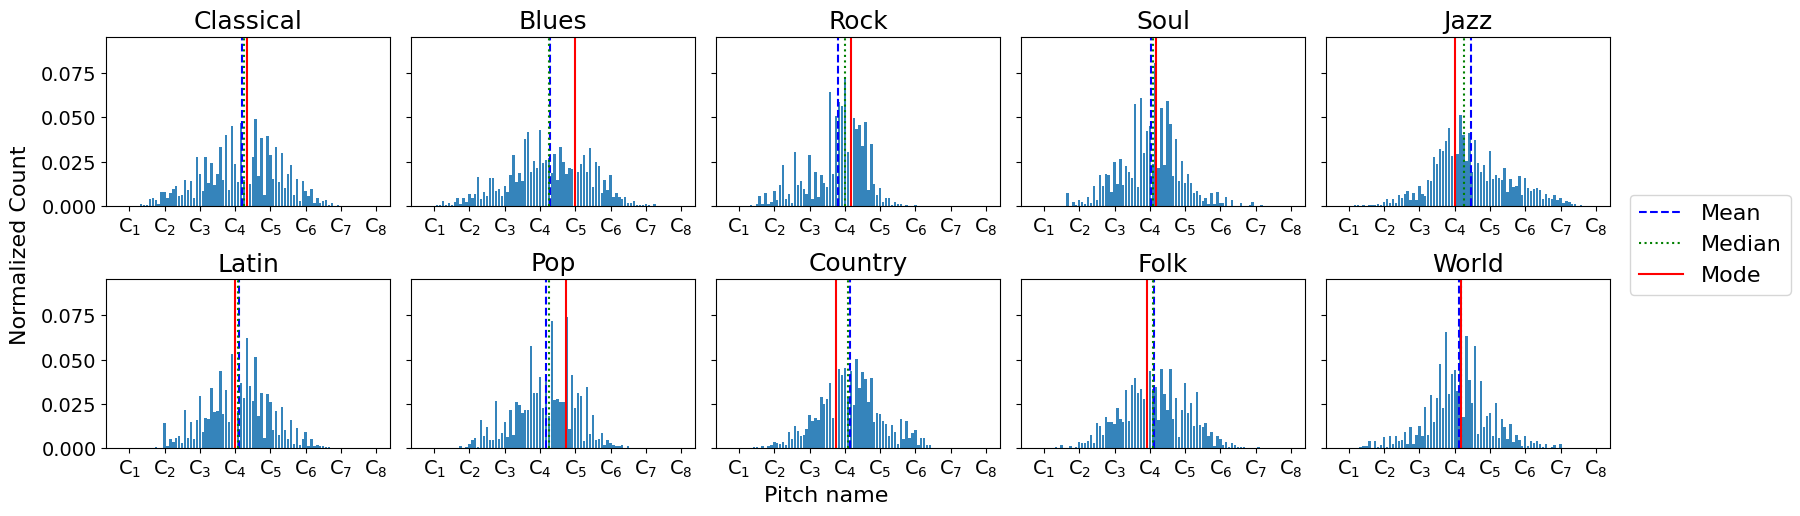

In [4]:
# plot pitch distribution per genre
pitch_names = [midi_pitch_to_name_formatted(p, formatted=False) for p in range(21, 109)]
bar_colors = [get_piano_key_color(p) for p in range(21, 109)]

fig, axs = plt.subplots(2, 5, figsize=(16, 5), sharex=False, sharey=True)

fs_title=16
fs_axis=14
fs_ticks=12

mean_pitches = np.zeros(len(genres))
median_pitches = np.zeros(len(genres))
mode_pitches = np.zeros(len(genres))

for i, genre in enumerate(genres):
    distribution = GENRE_PITCH_DIST_DICT[genre]
    normalized_distribution = distribution / np.sum(distribution)
    
    ax = axs[i // 5, i % 5]
    ax.bar(
        PITCH_NAMES, 
        normalized_distribution, 
        # color=bar_colors,
        alpha=0.9, 
        width=0.8
    )
    
    pitches = np.arange(21, 109)  # MIDI pitch range
    mean_pitch = np.sum(pitches * normalized_distribution) / np.sum(normalized_distribution)
    cumulative_distribution = np.cumsum(normalized_distribution / np.sum(normalized_distribution))
    median_pitch = pitches[np.searchsorted(cumulative_distribution, 0.5)]
    mode_pitch = pitches[np.argmax(normalized_distribution)]
    
    ax.axvline(mean_pitch-21, color='blue', linestyle='--', label='Mean')
    ax.axvline(median_pitch-21, color='green', linestyle=':', label='Median')
    ax.axvline(mode_pitch-21, color='red', linestyle='-', label='Mode')
    
    ax.set_title(genre, fontsize=fs_title+2)
    # x_ticks = [x for x in pitch_names if 'C' in x and '#' not in x]
    x_ticks = [x for x in PITCH_NAMES if 'C' in x and '{\sharp}' not in x]
    ax.set_xticks(x_ticks)
    ax.tick_params(axis='both', labelsize=fs_ticks+2)
    
    mean_pitch = int(np.round(mean_pitch-21))
    median_pitch = int(np.round(median_pitch-21))
    mode_pitch = int(np.round(mode_pitch-21))
    mean_pitches[i] = mean_pitch
    median_pitches[i] = median_pitch
    mode_pitches[i] = mode_pitch
    
    print(f"Genre: {genre:10s}, Mean: {pitch_names[mean_pitch]:3s}, Median: {pitch_names[median_pitch]:3s}, Mode: {pitch_names[mode_pitch]:3s}")

# mean, median, mode over all genres
mean_pitch = int(np.round(np.mean(mean_pitches)))
median_pitch = int(np.round(np.median(mean_pitches)))
mode_pitch = int(np.argmax(mode_pitches))
print(f'Overall mean pitch: {pitch_names[mean_pitch]}')
print(f'Overall median pitch: {pitch_names[median_pitch]}')
print(f'Overall mode pitch: {pitch_names[int(mode_pitches[np.argmax(mode_pitches)])]}')

fig.text(-0.01, 0.5, "Normalized Count", va='center', rotation='vertical', fontsize=fs_axis+2)
fig.text(0.5, -0.015, "Pitch name", ha='center', fontsize=fs_axis+2)

# add legend for the entire figure
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.07+.04, 0.5), fontsize=fs_axis+2)

plt.tight_layout()
plt.show()


In [5]:
# compare cosine similarity between genres
from itertools import combinations

GENRE_PITCH_DIST_DICT[genres[0]]
genre_pairs = list(combinations(genres, 2))
genre_pair_distances = dict()

for pair in genre_pairs:
    genre_1_dist = GENRE_PITCH_DIST_DICT[pair[0]]
    genre_1_dist_normalized = genre_1_dist / np.sum(genre_1_dist) 
    genre_2_dist = GENRE_PITCH_DIST_DICT[pair[1]]
    genre_2_dist_normalized = genre_2_dist / np.sum(genre_2_dist) 
    
    dot_product = np.dot(genre_1_dist_normalized, genre_2_dist_normalized)  
    magnitude_genre_1 = np.linalg.norm(genre_1_dist_normalized)
    magnitude_genre_2 = np.linalg.norm(genre_2_dist_normalized)

    cosine_similarity = dot_product / (magnitude_genre_1 * magnitude_genre_2)
    
    genre_pair_distances[pair] = cosine_similarity
    print(f'{pair[0]:9} - {pair[1]:7}: {cosine_similarity:.3f}')

Classical - Blues  : 0.819
Classical - Rock   : 0.780
Classical - Soul   : 0.888
Classical - Jazz   : 0.811
Classical - Latin  : 0.925
Classical - Pop    : 0.900
Classical - Country: 0.896
Classical - Folk   : 0.922
Classical - World  : 0.908
Blues     - Rock   : 0.740
Blues     - Soul   : 0.753
Blues     - Jazz   : 0.918
Blues     - Latin  : 0.840
Blues     - Pop    : 0.758
Blues     - Country: 0.837
Blues     - Folk   : 0.884
Blues     - World  : 0.791
Rock      - Soul   : 0.924
Rock      - Jazz   : 0.869
Rock      - Latin  : 0.871
Rock      - Pop    : 0.768
Rock      - Country: 0.897
Rock      - Folk   : 0.827
Rock      - World  : 0.910
Soul      - Jazz   : 0.850
Soul      - Latin  : 0.902
Soul      - Pop    : 0.865
Soul      - Country: 0.946
Soul      - Folk   : 0.876
Soul      - World  : 0.947
Jazz      - Latin  : 0.875
Jazz      - Pop    : 0.808
Jazz      - Country: 0.923
Jazz      - Folk   : 0.897
Jazz      - World  : 0.890
Latin     - Pop    : 0.883
Latin     - Country: 0.939
L

## Pitch class distribution

In [6]:
# aggregate pitch class distributions across genres
GENRE_PITCH_CLASS_DIST_DICT = dict()

for k, v in GENRE_PITCH_DIST_DICT.items():
    GENRE_PITCH_CLASS_DIST_DICT[k] = note_to_pitch_class_distribution(v)
    
GENRE_PITCH_CLASS_DIST_DICT

{'Classical': array([1411.,  771., 2017.,  851., 1968.,  680., 1179., 2077.,  848.,
        1821.,  379., 2188.]),
 'Blues': array([2853., 1395., 1835., 2480., 1347., 2145., 1071., 2614., 2521.,
        1227., 1715., 1347.]),
 'Rock': array([1142.,  384., 1207.,  784.,  633.,  651.,  464., 1429.,  385.,
        1030.,  785.,  681.]),
 'Soul': array([ 795.,  519., 1144.,  413.,  824.,  537.,  730., 1148.,  423.,
        1122.,  585.,  778.]),
 'Jazz': array([2162., 1233., 1607., 1580., 1232., 1949., 1087., 1821., 1464.,
        1372., 1800., 1032.]),
 'Latin': array([1144.,  345.,  677.,  460., 1014.,  594.,  460., 1059.,  376.,
         730.,  222.,  837.]),
 'Pop': array([ 644.,  516.,  740.,  249., 1159.,  521.,  623.,  446.,  452.,
        1302.,  389.,  674.]),
 'Country': array([ 857.,  564.,  727.,  504.,  845.,  702.,  700.,  927.,  530.,
        1017.,  650.,  725.]),
 'Folk': array([856., 672., 682., 404., 990., 527., 711., 921., 521., 745., 420.,
        758.]),
 'World': arr

### Figure 18

Genre: Classical  Mean: F# ,             Median: F# ,             Mode: B  
Genre: Blues      Mean: F  ,             Median: F  ,             Mode: C  
Genre: Rock       Mean: F  ,             Median: F  ,             Mode: G  
Genre: Soul       Mean: F# ,             Median: F# ,             Mode: G  
Genre: Jazz       Mean: F  ,             Median: F  ,             Mode: C  
Genre: Latin      Mean: F  ,             Median: F  ,             Mode: C  
Genre: Pop        Mean: F# ,             Median: F# ,             Mode: A  
Genre: Country    Mean: F# ,             Median: F# ,             Mode: A  
Genre: Folk       Mean: F  ,             Median: F  ,             Mode: E  
Genre: World      Mean: F  ,             Median: F  ,             Mode: G  


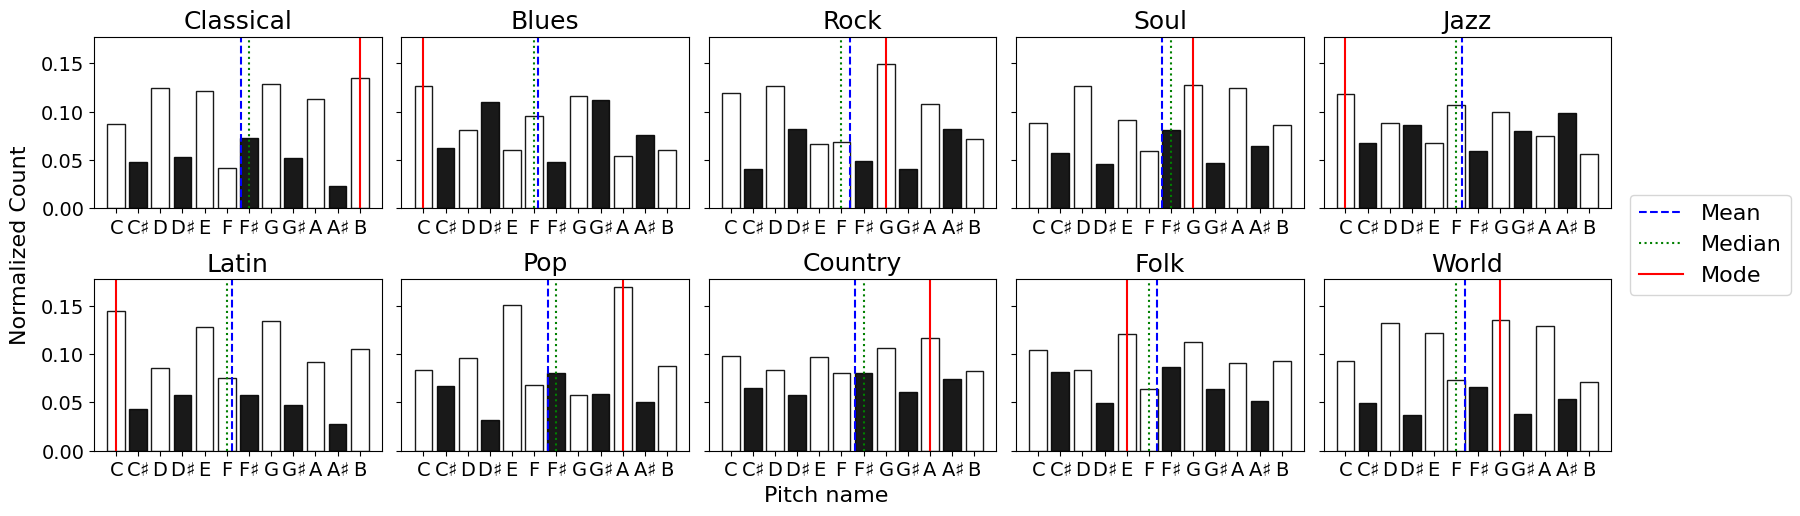

In [7]:
pitch_class_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

def format_pitch_class(pitch_class):
    return fr"$\mathregular{{{pitch_class}}}$"
    
pitch_class_names_formatted = ['C', 'C{\sharp}', 'D', 'D{\sharp}', 'E', 'F', 'F{\sharp}', 'G', 'G{\sharp}', 'A', 'A{\sharp}', 'B']
pitch_class_names_formatted = [format_pitch_class(p) for p in pitch_class_names_formatted]
pitch_class_colors = ['black' if i in {1,3,6,8,10} else 'white' for i in range(12)]

fig, axs = plt.subplots(2, 5, figsize=(16, 5), sharex=False, sharey=True)

mean_pitches = np.zeros(len(genres))
median_pitches = np.zeros(len(genres))
mode_pitches = np.zeros(len(genres))

for i, genre in enumerate(genres):
    distribution = GENRE_PITCH_CLASS_DIST_DICT[genre]
    normalized_distribution = distribution / np.sum(distribution)
    
    ax = axs[i // 5, i % 5]
    ax.bar(
        pitch_class_names_formatted, 
        normalized_distribution, 
        color=pitch_class_colors,
        edgecolor='black',
        alpha=0.9, 
        width=0.8
    )
    
    pitches = np.arange(12)  # pitch classes
    mean_pitch = np.sum(pitches * normalized_distribution) / np.sum(normalized_distribution)
    cumulative_distribution = np.cumsum(normalized_distribution / np.sum(normalized_distribution))
    median_pitch = pitches[np.searchsorted(cumulative_distribution, 0.5)]
    mode_pitch = pitches[np.argmax(normalized_distribution)]
    
    ax.axvline(mean_pitch, color='blue', linestyle='--', label='Mean')
    ax.axvline(median_pitch, color='green', linestyle=':', label='Median')
    ax.axvline(mode_pitch, color='red', linestyle='-', label='Mode')
    
    ax.set_title(genre, fontsize=fs_title+2)
    x_ticks = [x for x in pitch_class_names_formatted if not '{\sharp}' in x]
    # ax.set_xticks(x_ticks)
    ax.set_xticks(pitch_class_names_formatted)
    # ax.tick_params(labelsize=8, rotation=0.45)
    ax.tick_params(axis='both', labelsize=fs_ticks+2)
    
    mean_pitch = int(np.round(mean_pitch))
    median_pitch = int(np.round(median_pitch))
    mode_pitch = int(np.round(mode_pitch))
    mean_pitches[i] = mean_pitch
    median_pitches[i] = median_pitch
    mode_pitches[i] = mode_pitch
    
    print(f"Genre: {genre:10s} Mean: {pitch_class_names[mean_pitch]:3s}, \
            Median: {pitch_class_names[median_pitch]:3s}, \
            Mode: {pitch_class_names[mode_pitch]:3s}"
    )
fig.text(-0.01, 0.5, "Normalized Count", va='center', rotation='vertical', fontsize=fs_axis+2)
fig.text(0.5, -0.015, "Pitch name", ha='center', fontsize=fs_axis+2)

# add legend for the entire figure
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.07+0.04, 0.5), fontsize=fs_axis+2)

plt.tight_layout()
plt.show()

## Note density

In [8]:
# get note density (num notes per second)
note_density_df = pd.DataFrame(columns=['genre', 'duration_sec', 'num_notes', 'density', 'midi_path'])

genres = genre_meta['genre'].unique()
for genre in genres:
    midi_files = genre_meta[genre_meta['genre'] == genre]['mds_file'].values
    
    for mf in midi_files:
        midi_path = os.path.join(DATA_GENRE_PATH, f'{mf}.mid')
        pm = pretty_midi.PrettyMIDI(midi_path)
        dur_sec = pm.get_end_time()
        
        nnotes = sum(len(instr.notes) for instr in pm.instruments)
        ndensity = nnotes / dur_sec if dur_sec > 0 else 0
        
        track_dict = {
            'genre': genre,
            'duration_sec': [dur_sec],
            'num_notes': [nnotes],
            'density': [ndensity],
            'path': midi_path
        }
        
        _df = pd.DataFrame.from_dict(track_dict)
        
        if note_density_df.shape[0] == 0:
            note_density_df = _df
        else:    
            note_density_df = pd.concat([note_density_df, _df])

note_density_df.reset_index(inplace=True)
display(note_density_df)

,index,genre,duration_sec,num_notes,density,path
0,0,Classical,177.941982,1479,8.311698,../data/1_genre/Classical_01.mid
1,0,Classical,163.630420,2232,13.640495,../data/1_genre/Classical_02.mid
2,0,Classical,234.666784,1002,4.269884,../data/1_genre/Classical_03.mid
3,0,Classical,203.047547,647,3.186446,../data/1_genre/Classical_04.mid
4,0,Classical,154.037939,2082,13.516151,../data/1_genre/Classical_05.mid
...,...,...,...,...,...,...
95,0,World,185.390685,463,2.497429,../data/1_genre/World_06.mid
96,0,World,227.525000,811,3.564443,../data/1_genre/World_07.mid
97,0,World,120.346315,725,6.024281,../data/1_genre/World_08.mid
98,0,World,229.869900,978,4.254581,../data/1_genre/World_09.mid


### Figure 19

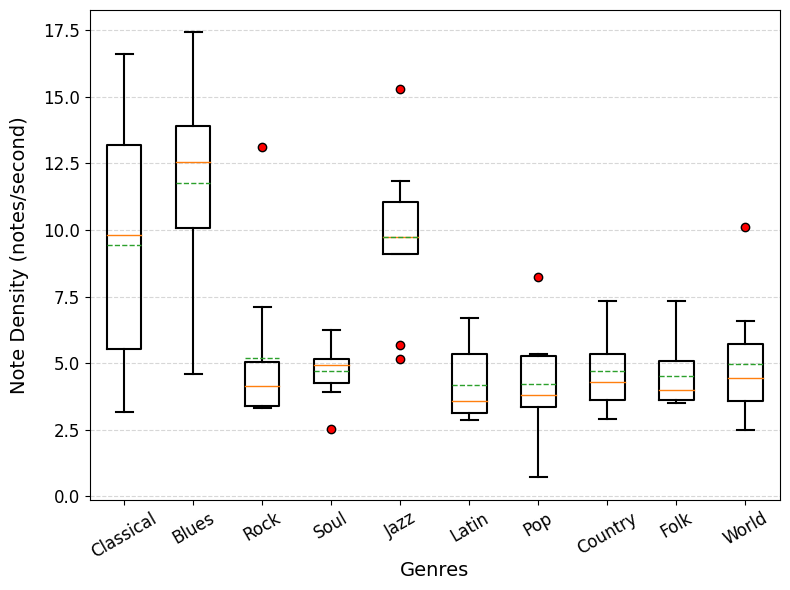

In [9]:
# plot densities per genre
GENRE_DENSITIES_DICT = note_density_df.groupby('genre')['density'].agg(list).to_dict()
genres_sorted = ['Classical', 'Blues', 'Rock', 'Soul', 'Jazz', 'Latin', 'Pop', 'Country', 'Folk', 'World']
GENRE_DENSITIES_DICT = {key: GENRE_DENSITIES_DICT[key] for key in genres_sorted if key in GENRE_DENSITIES_DICT} 

plt.figure(figsize=(8, 6))

boxplot =  plt.boxplot(
    GENRE_DENSITIES_DICT.values(), 
    showmeans=True,  # mean with a marker
    meanline=True,
    boxprops={'linewidth': 1.5},
    whiskerprops={'linewidth': 1.5},  # whisker lines
    capprops={'linewidth': 1.5},  # caps
    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 6, 'linestyle': 'none'}  # outliers
    )
    # mean = dashed line
    # median = solid line
    
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.gca().set_xticklabels(GENRE_DENSITIES_DICT.keys(), rotation=30, fontsize=fs_ticks)
plt.yticks(fontsize=fs_ticks)

plt.xlabel('Genres', fontsize=fs_axis, labelpad=0)
plt.ylabel('Note Density (notes/second)', fontsize=fs_axis, labelpad=10)

plt.tight_layout()
plt.show()


### Figure 20

In [10]:
# aggregate polyphony as proportions over all polyphonic onsets, split by genre
genres = genre_meta['genre'].unique()
GENRE_POLYPHONY_PROPORTIONS = dict()
for genre in genres:
    midi_files = genre_meta[genre_meta['genre'] == genre]['mds_file'].values
    
    genre_piano_rolls = []
    for mf in midi_files:
        midi_path = os.path.join(DATA_GENRE_PATH, f'{mf}.mid')
        piano_roll = midi_to_piano_roll(midi_path)
        genre_piano_rolls.append(piano_roll)
        GENRE_POLYPHONY_PROPORTIONS[genre] = compute_polyphony_proportions(genre_piano_rolls)

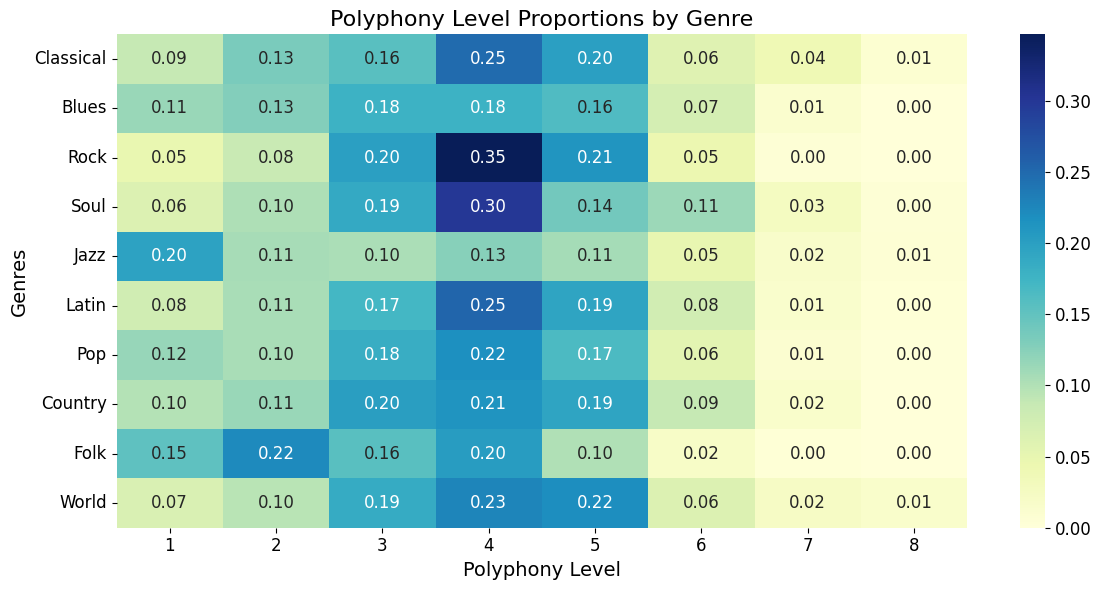

In [11]:
# create heatmap
n_polyphony = 8
polyphony_levels = range(1, n_polyphony+1)
genre_labels = list(GENRE_POLYPHONY_PROPORTIONS.keys())
proportions_matrix = np.array([GENRE_POLYPHONY_PROPORTIONS[genre][1:n_polyphony+1] for genre in genre_labels])

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(proportions_matrix, annot=True, fmt=".2f", cmap="YlGnBu", xticklabels=polyphony_levels, yticklabels=genre_labels, ax=ax, annot_kws={"fontsize": 12})

ax.set_xlabel("Polyphony Level", fontsize=fs_axis)
ax.set_ylabel("Genres", fontsize=fs_axis)
ax.set_title("Polyphony Level Proportions by Genre", fontsize=fs_title)
ax.tick_params(axis='both', labelsize=fs_ticks)
ax.collections[0].colorbar.ax.tick_params(labelsize=fs_ticks)
plt.tight_layout()
plt.show()

## Harmonic interval and chord distribution

### Count

In [12]:
HARMONIC_INTERVALS_DF = pd.DataFrame()

genres = genre_meta['genre'].unique()
for genre in genres:
    midi_files = genre_meta[genre_meta['genre'] == genre]['mds_file'].values
    
    for mi, mf in enumerate(midi_files):
        midi_path = os.path.join(DATA_GENRE_PATH, f'{mf}.mid')
        note_events = list_notes_in_dicts(midi_path)
        
        # get counts of harmonic chords
        interval_dict = count_harmonic_chords(note_events)
        interval_df = pd.DataFrame.from_dict([interval_dict])
        interval_df['genre'] = genre
        interval_df['mf'] = mf
    
        HARMONIC_INTERVALS_DF = pd.concat([HARMONIC_INTERVALS_DF, interval_df]).fillna(0)
        
display(HARMONIC_INTERVALS_DF.head(5))
print(f'{HARMONIC_INTERVALS_DF.shape[1]-2} harmonic intervals/chords found')


,[0],"[0, 1]","[0, 2]","[0, 3]","[0, 4]","[0, 5]","[0, 6]","[0, 7]","[0, 8]","[0, 9]",...,"[0, 1, 4, 5, 9, 10, 12]","[0, 2, 3, 4, 7, 10, 12]","[0, 2, 3, 5, 6, 10, 11]","[0, 3, 5, 7, 8, 11, 12]","[0, 4, 7, 9, 10, 11, 12]","[0, 1, 2, 3, 4, 5, 7, 10]","[0, 1, 4, 5, 7, 9, 10, 12]","[0, 2, 3, 5, 6, 10, 11, 12]","[0, 2, 3, 5, 6, 7, 10, 11, 12]","[0, 2, 3, 4, 6, 7, 9, 10, 11, 12]"
0,1.0,35.0,26.0,48,25,41,29.0,50.0,24.0,11.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,0.0,17.0,17.0,79,76,23,8.0,29.0,65.0,40.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,0.0,0.0,12.0,46,52,49,13.0,17.0,4.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,0.0,1.0,13.0,13,15,17,1.0,10.0,19.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,0.0,160.0,95.0,51,43,79,19.0,62.0,7.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


1156 harmonic intervals/chords found


In [13]:
# filter intervals and chords
cols = HARMONIC_INTERVALS_DF.columns.tolist()
interval_cols = ['genre', 'mf', *[c for c in cols if c.count(',')==1]]
trichord_cols = ['genre', 'mf', *[c for c in cols if c.count(',')==2]]
tetrachord_cols = ['genre', 'mf', *[c for c in cols if c.count(',')==3]]

print(len(interval_cols)-2, 'intervals')
print(len(trichord_cols)-2, 'trichord combinations')
print(len(tetrachord_cols)-2, 'tetrachords combinations')
print()
print(len(cols)-len(interval_cols)-len(trichord_cols)-len(tetrachord_cols)-8, 'remaining chord combis:')
for i in range(5,12):
    print(f"{i} notes: {len([c for c in cols if c.count(',')==i-1])}")

12 intervals
66 trichord combinations
215 tetrachords combinations

851 remaining chord combis:
5 notes: 359
6 notes: 301
7 notes: 153
8 notes: 41
9 notes: 7
10 notes: 1
11 notes: 0


### Interval distribution

### Figure 21

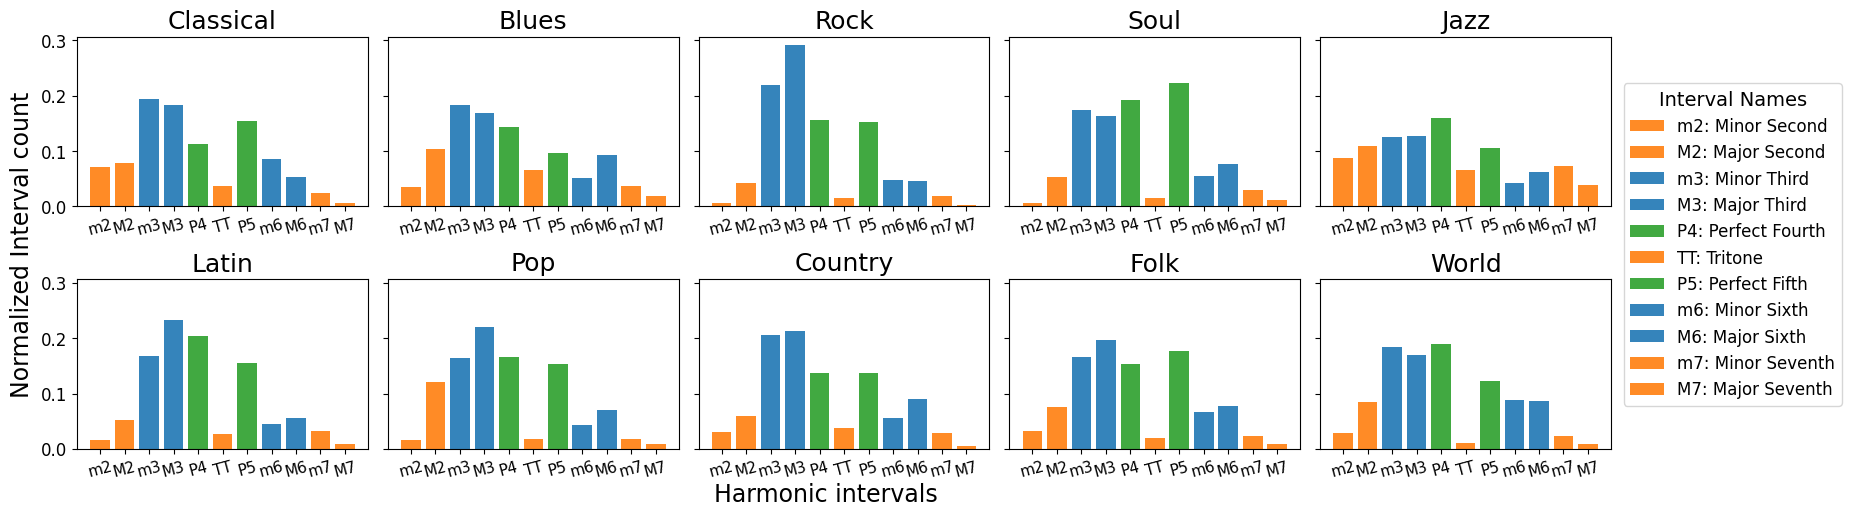

In [14]:
# plot intervals
interval_df = HARMONIC_INTERVALS_DF[interval_cols].copy()

interval_names = [
    "Minor Second",   # 1 semitone
    "Major Second",   # 2 semitones
    "Minor Third",    # 3 semitones
    "Major Third",    # 4 semitones
    "Perfect Fourth", # 5 semitones
    "Tritone",        # 6 semitones (Augmented Fourth/Diminished Fifth)
    "Perfect Fifth",  # 7 semitones
    "Minor Sixth",    # 8 semitones
    "Major Sixth",    # 9 semitones
    "Minor Seventh",  # 10 semitones
    "Major Seventh",  # 11 semitones
]

interval_names_plot = ["m2", "M2", "m3", "M3", "P4", "TT", "P5", "m6", "M6", "m7", "M7"]
colors = ['#ff7f0e', '#ff7f0e', '#1f77b4', '#1f77b4', '#2ca02c', '#ff7f0e', '#2ca02c', '#1f77b4', '#1f77b4', '#ff7f0e', '#ff7f0e'] 

fig, axs = plt.subplots(2, 5, figsize=(16, 5), sharex=False, sharey=True)

interval_df.drop(columns='mf', inplace=True)
interval_df.drop(columns='[0, 12]', inplace=True)
for i, genre in enumerate(genres):
    g = interval_df[interval_df['genre'] == genre]
    interval_counts = g.drop(columns='genre').sum().values
    interval_counts_normalized = interval_counts / np.sum(interval_counts)
    
    ax = axs[i // 5, i % 5]
    ax.bar(
        interval_names_plot, 
        interval_counts_normalized, 
        color=colors,
        alpha=0.9, 
        width=0.8,
        label = interval_names
    )
    ax.set_title(genre, fontsize=fs_title+2)
    ax.tick_params(axis='x', rotation=15, labelsize=fs_ticks-1)
    ax.tick_params(axis='y', rotation=0, labelsize=fs_ticks)
    
fig.text(-0.01, 0.5, "Normalized Interval count", va='center', rotation='vertical', fontsize=fs_axis+3)
fig.text(0.5, -0.015, "Harmonic intervals", ha='center', fontsize=fs_axis+3)

# add legend for the entire figure
handles, labels = ax.get_legend_handles_labels()

legend_labels = [f"{short}: {full}" for short, full in zip(interval_names_plot, interval_names)]
fig.legend(legend_labels, title="Interval Names", loc='center right', bbox_to_anchor=(1.12+0.02, 0.5), numpoints=len(legend_labels),
    fontsize=fs_axis-2, title_fontsize=fs_axis)
plt.tight_layout()
plt.show()

### Triad distribution

In [15]:
# retrieve trichords, then summarize the equivalent forms and aggregate per genre
triads_df = HARMONIC_INTERVALS_DF[trichord_cols]
triads_equivalent_grouped_df = summarize_equivalent_chords(triads_df, TRIADS_DICT)
display(triads_equivalent_grouped_df)

,genre,Major Triad,Minor Triad,Diminished Triad,Augmented Triad,Suspended
0,Blues,539.0,225.0,241.0,36.0,63.0
1,Classical,588.0,286.0,101.0,24.0,60.0
2,Country,456.0,118.0,54.0,54.0,49.0
3,Folk,350.0,197.0,28.0,0.0,87.0
4,Jazz,261.0,273.0,126.0,129.0,194.0
5,Latin,387.0,156.0,43.0,30.0,35.0
6,Pop,361.0,182.0,24.0,6.0,104.0
7,Rock,743.0,180.0,28.0,12.0,39.0
8,Soul,488.0,223.0,26.0,15.0,50.0
9,World,640.0,234.0,34.0,6.0,93.0


### Figure 22

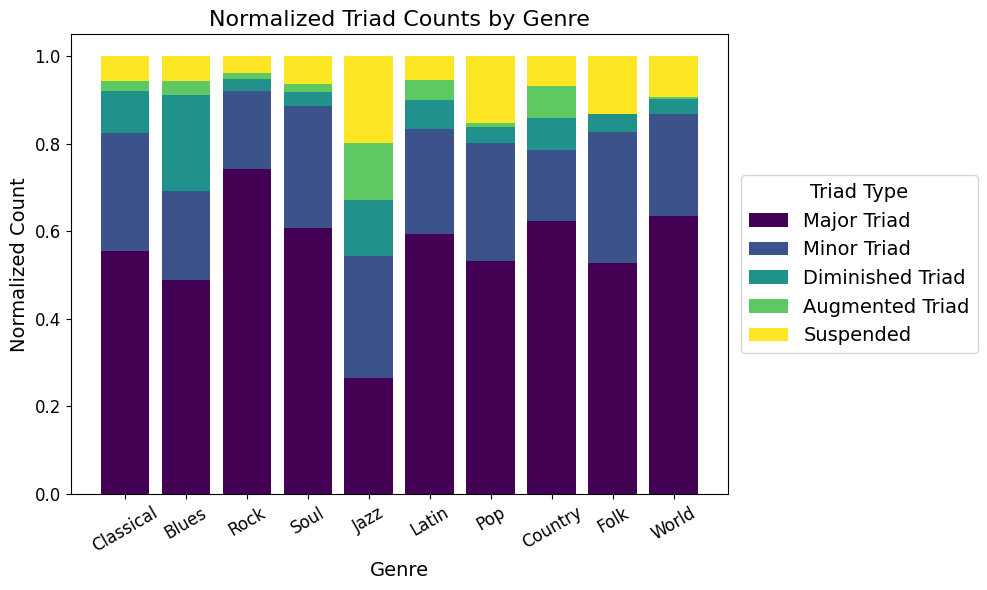

In [16]:
# normalize counts
triads_equivalent_grouped_df_normalized = triads_equivalent_grouped_df.copy()
triads_equivalent_grouped_df_normalized.iloc[:, 1:] = triads_equivalent_grouped_df.iloc[:, 1:].div(triads_equivalent_grouped_df.iloc[:, 1:].sum(axis=1), axis=0)

# plot as a stacked bar chart
plt.figure(figsize=(10, 6))

# bar order
genre_order = ['Classical', 'Blues', 'Rock', 'Soul', 'Jazz', 'Latin', 'Pop', 'Country', 'Folk', 'World']
# reindex
triads_equivalent_grouped_df_normalized = triads_equivalent_grouped_df_normalized.set_index('genre').loc[genre_order].reset_index()

bottom = np.zeros(len(triads_equivalent_grouped_df_normalized))
colors = plt.cm.viridis(np.linspace(0, 1, len(triads_equivalent_grouped_df_normalized.columns[1:])))
for col, color in zip(triads_equivalent_grouped_df_normalized.columns[1:], colors):
    plt.bar(triads_equivalent_grouped_df_normalized['genre'], triads_equivalent_grouped_df_normalized[col], bottom=bottom, label=col, color=color)
    bottom += triads_equivalent_grouped_df_normalized[col].values

plt.title('Normalized Triad Counts by Genre', fontsize=fs_title)
plt.xlabel('Genre', fontsize=fs_axis)
plt.ylabel('Normalized Count', fontsize=fs_axis)
plt.xticks(rotation=30, fontsize=fs_ticks)
plt.yticks(fontsize=fs_ticks)
plt.legend(title='Triad Type', bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0, fontsize=fs_axis, title_fontsize=fs_axis)

plt.tight_layout()
plt.show()

### Seventh chord distribution

In [17]:
# retrieve tetrachords, then summarize the equivalent forms and aggregate per genre
seventh_chord_df = HARMONIC_INTERVALS_DF[tetrachord_cols]
seventh_chord_equivalent_grouped_df = summarize_equivalent_chords(seventh_chord_df, SEVENTH_CHORDS_DICT)
display(seventh_chord_equivalent_grouped_df)

,genre,Major Seventh,Dominant Seventh,Minor Seventh,Diminished Seventh,Half-Diminished Seventh,Minor-Major Seventh
0,Blues,19.0,136.0,108.0,116.0,32.0,8.0
1,Classical,47.0,81.0,73.0,56.0,29.0,10.0
2,Country,16.0,37.0,30.0,16.0,4.0,7.0
3,Folk,28.0,21.0,36.0,8.0,8.0,0.0
4,Jazz,129.0,55.0,169.0,124.0,52.0,22.0
5,Latin,17.0,18.0,36.0,32.0,6.0,0.0
6,Pop,19.0,16.0,78.0,16.0,7.0,0.0
7,Rock,14.0,123.0,59.0,8.0,5.0,0.0
8,Soul,33.0,14.0,80.0,0.0,2.0,0.0
9,World,59.0,21.0,61.0,12.0,1.0,2.0


### Figure 23

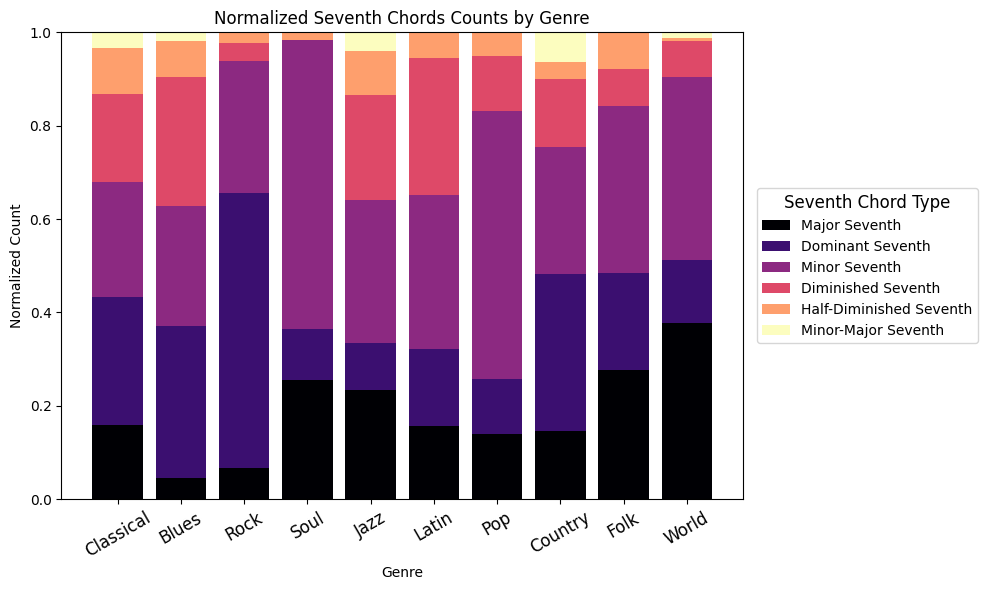

In [18]:
# normalize counts
seventh_chord_equivalent_grouped_normalized = seventh_chord_equivalent_grouped_df.copy()
seventh_chord_equivalent_grouped_normalized.iloc[:, 1:] = seventh_chord_equivalent_grouped_df.iloc[:, 1:].div(seventh_chord_equivalent_grouped_df.iloc[:, 1:].sum(axis=1), axis=0)

# desired bar order
genre_order = ['Classical', 'Blues', 'Rock', 'Soul', 'Jazz', 'Latin', 'Pop', 'Country', 'Folk', 'World']
# reindex
seventh_chord_equivalent_grouped_normalized = seventh_chord_equivalent_grouped_normalized.set_index('genre').loc[genre_order].reset_index()

# for name, color_palette in color_palette_dict.items():
plt.figure(figsize=(10, 6))
bottom = np.zeros(len(seventh_chord_equivalent_grouped_normalized))
colors = plt.cm.magma(np.linspace(0, 1, len(seventh_chord_equivalent_grouped_normalized.columns[1:])))

for col, color in zip(seventh_chord_equivalent_grouped_normalized.columns[1:], colors):
    plt.bar(seventh_chord_equivalent_grouped_normalized['genre'], seventh_chord_equivalent_grouped_normalized[col], bottom=bottom, label=col, color=color)
    bottom += seventh_chord_equivalent_grouped_normalized[col].values

plt.title('Normalized Seventh Chords Counts by Genre', fontsize=12)
plt.xlabel('Genre', fontsize=10)
plt.ylabel('Normalized Count', fontsize=10)
plt.xticks(rotation=30, fontsize=fs_ticks)
plt.yticks(fontsize=10)
plt.legend(title='Seventh Chord Type', bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0, fontsize=10, title_fontsize=12)

plt.tight_layout()
plt.show()

## Velocity

In [19]:
# aggregate velocity distribution per genre
VELOCITY_DISTRIBUTION_PER_GENRE = {genre: np.zeros(128, dtype=int) for genre in genres}

for genre in genres:
    midi_files = genre_meta[genre_meta['genre'] == genre]['mds_file'].values
    
    for mf in midi_files:
        midi_path = os.path.join(DATA_GENRE_PATH, f'{mf}.mid')
        pm = pretty_midi.PrettyMIDI(midi_path)
        velocities = [note.velocity for instrument in pm.instruments for note in instrument.notes]
        velocity_counts = pd.Series(velocities).value_counts().sort_index()
        
        for velocity, count in velocity_counts.items():
            VELOCITY_DISTRIBUTION_PER_GENRE[genre][velocity] += count

### Figure 24

Overall mean vel: 77
Overall median vel: 80
Overall mode vel: 0


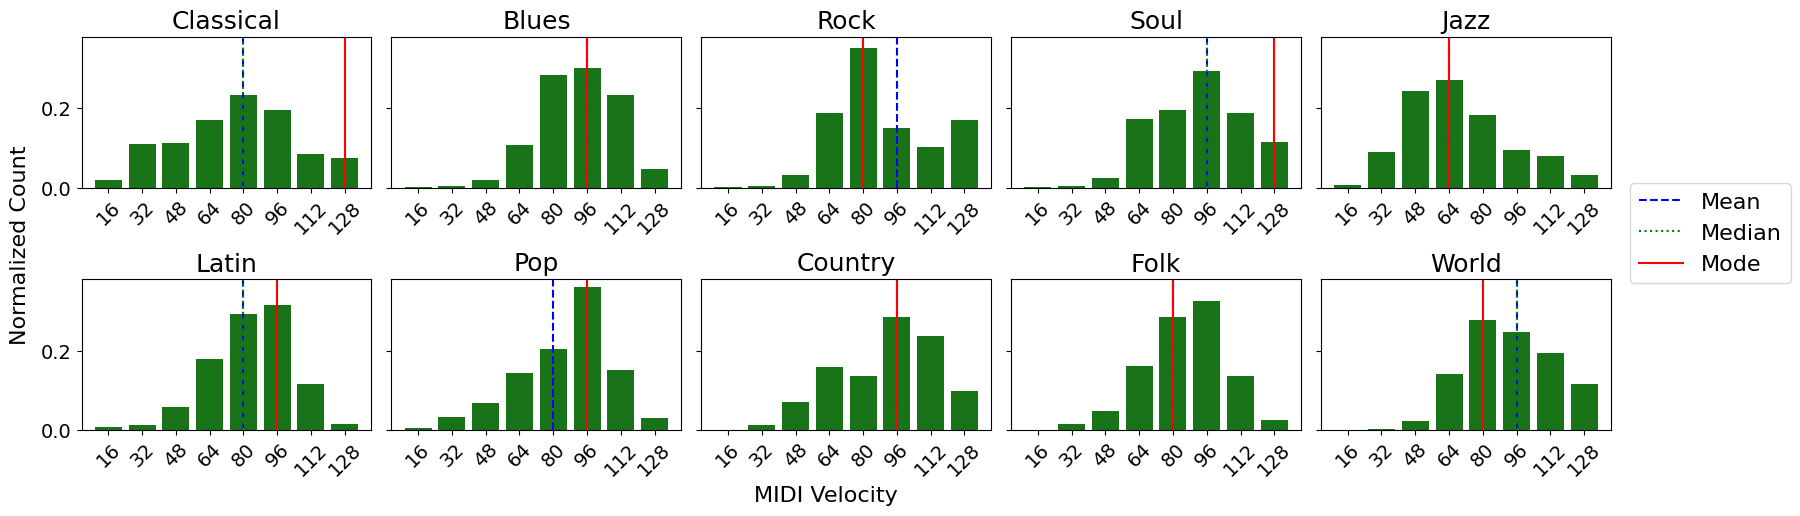

In [20]:
# bin the velocities
bins = [0, 16, 32, 48, 64, 80, 96, 112, 128]
bin_labels = [str(i) for i in bins[1:]]

# plot
fig, axs = plt.subplots(2, 5, figsize=(16, 5), sharex=False, sharey=True)

mean_vels = np.zeros(len(genres))
median_vels = np.zeros(len(genres))
mode_vels = np.zeros(len(genres))

for i, genre in enumerate(genres):
    distribution = VELOCITY_DISTRIBUTION_PER_GENRE[genre]
    normalized_distribution = distribution / np.sum(distribution)
    
    # bin the distribution
    binned_distribution = pd.cut(np.arange(128), bins=bins, labels=bin_labels, right=False)
    binned_counts = pd.Series(normalized_distribution).groupby(binned_distribution, observed=False).sum()
    
    ax = axs[i // 5, i % 5]
    ax.bar(
        bin_labels, 
        binned_counts, 
        alpha=0.9, 
        width=0.8,
        color='darkgreen'
    )
    
    mean_vel = np.sum(np.arange(128) * normalized_distribution)
    cumulative_distribution = np.cumsum(normalized_distribution)
    median_vel = np.arange(128)[np.searchsorted(cumulative_distribution, 0.5)]
    mode_vel = np.argmax(normalized_distribution)
    
    ax.axvline(mean_vel // 16, color='blue', linestyle='--', label='Mean')
    ax.axvline(median_vel // 16, color='green', linestyle=':', label='Median')
    ax.axvline(mode_vel // 16, color='red', linestyle='-', label='Mode')
    
    ax.set_title(genre, fontsize=fs_title+2)
    ax.set_xticks(range(len(bin_labels)))
    ax.set_xticklabels(bin_labels, rotation=45)
    ax.tick_params(axis='both', labelsize=fs_ticks+2)
    
    mean_vel = int(np.round(mean_vel))
    median_vel = int(np.round(median_vel))
    mode_vel = int(np.round(mode_vel))
    mean_vels[i] = mean_vel
    median_vels[i] = median_vel
    mode_vels[i] = mode_vel
    
# mean, median, mode over all genres
mean_vel = int(np.round(np.mean(mean_vels)))
median_vel = int(np.round(np.median(mean_vels)))
mode_vel = int(np.argmax(mode_vels))
print(f'Overall mean vel: {mean_vel}')
print(f'Overall median vel: {median_vel}')
print(f'Overall mode vel: {mode_vel}')

fig.text(-0.01, 0.5, "Normalized Count", va='center', rotation='vertical', fontsize=fs_axis+2)
fig.text(0.5, -0.015, "MIDI Velocity", ha='center', fontsize=fs_axis+2)

# add legend for the entire figure
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.07+0.04, 0.5+0.0225), fontsize=fs_axis+2)

plt.tight_layout()
plt.show()